In [4]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, Dataset

plt.style.use("seaborn-v0_8-whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

df = pd.read_csv(r"C:\Users\ASUS\Downloads\Electric_Production.csv")
df["DATE"] = pd.to_datetime(df["DATE"], dayfirst=True)
df = df.sort_values("DATE").reset_index(drop=True)
series = df[["Value"]].astype(float).values

roll_no = "102317167"
window_size = (sum(int(digit) for digit in roll_no) % 10) + 8
prediction_horizon = (int(roll_no[-2:]) % 3) + 1
hidden_size = (int(roll_no[:3]) % 16) + 8
print(f"Roll no {roll_no} -> window_size={window_size}, prediction_horizon={prediction_horizon}, hidden_size={hidden_size}")

train_cut = int(len(series) * 0.70)
val_cut = int(len(series) * 0.85)
scaler = MinMaxScaler()
scaler.fit(series[:train_cut])
scaled_data = scaler.transform(series)
print("Series length:", len(series), "Train/Val/Test target cuts:", train_cut, val_cut)


def create_supervised_sequences(data, window, horizon):
    features, targets, target_indices = [], [], []
    limit = len(data) - horizon + 1
    for end in range(window, limit):
        target_index = end + horizon - 1
        features.append(data[end - window:end])
        targets.append(data[target_index])
        target_indices.append(target_index)
    return np.asarray(features, dtype=np.float32), np.asarray(targets, dtype=np.float32), np.asarray(target_indices, dtype=np.int64)


def split_by_target_index(features, targets, target_indices, train_end, val_end):
    train_mask = target_indices < train_end
    val_mask = (target_indices >= train_end) & (target_indices < val_end)
    test_mask = target_indices >= val_end
    return (
        features[train_mask], targets[train_mask],
        features[val_mask], targets[val_mask],
        features[test_mask], targets[test_mask],
    )


class SequenceDataset(Dataset):
    def __init__(self, features, targets):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        return self.features[index], self.targets[index]


class MLPBaseline(nn.Module):
    def __init__(self, window, hidden):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(window, hidden * 2),
            nn.ReLU(),
            nn.Linear(hidden * 2, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return self.network(x).squeeze(-1)


class CustomGRUCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.Wz = nn.Linear(input_size, hidden_size)
        self.Uz = nn.Linear(hidden_size, hidden_size, bias=False)
        self.Wr = nn.Linear(input_size, hidden_size)
        self.Ur = nn.Linear(hidden_size, hidden_size, bias=False)
        self.Wh = nn.Linear(input_size, hidden_size)
        self.Uh = nn.Linear(hidden_size, hidden_size, bias=False)

    def forward(self, x_t, h_prev):
        z = torch.sigmoid(self.Wz(x_t) + self.Uz(h_prev))
        r = torch.sigmoid(self.Wr(x_t) + self.Ur(h_prev))
        candidate = torch.tanh(self.Wh(x_t) + self.Uh(r * h_prev))
        return (1 - z) * h_prev + z * candidate


class CustomGRUForecaster(nn.Module):
    def __init__(self, hidden):
        super().__init__()
        self.cell = CustomGRUCell(1, hidden)
        self.head = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        batch_size, seq_len, _ = x.shape
        hidden_state = torch.zeros(batch_size, self.cell.hidden_size, device=x.device)
        for step in range(seq_len):
            hidden_state = self.cell(x[:, step, :], hidden_state)
        return self.head(hidden_state).squeeze(-1)


class LSTMForecaster(nn.Module):
    def __init__(self, hidden):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden, batch_first=True)
        self.head = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        outputs, _ = self.lstm(x)
        return self.head(outputs[:, -1, :]).squeeze(-1)


class PositionalEncoding(nn.Module):
    def __init__(self, hidden, max_len=128, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        positions = torch.arange(max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, hidden, 2, dtype=torch.float32) * (-np.log(10000.0) / hidden))
        pe = torch.zeros(max_len, hidden)
        pe[:, 0::2] = torch.sin(positions * div_term)
        pe[:, 1::2] = torch.cos(positions * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1), :])


class TransformerForecaster(nn.Module):
    def __init__(self, hidden):
        super().__init__()
        self.input_projection = nn.Linear(1, hidden)
        self.position_encoding = PositionalEncoding(hidden)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden,
            nhead=2,
            dim_feedforward=hidden * 4,
            dropout=0.1,
            batch_first=True,
            activation="relu",
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.head = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        encoded = self.input_projection(x)
        encoded = self.position_encoding(encoded)
        encoded = self.encoder(encoded)
        return self.head(encoded[:, -1, :]).squeeze(-1)


def train_model(model, train_loader, val_loader, epochs=90, lr=1e-3, patience=12):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    best_state = None
    best_val_loss = float("inf")
    patience_counter = 0
    history = {"train_loss": [], "val_loss": []}

    for _ in range(epochs):
        model.train()
        train_loss = 0.0
        for features, targets in train_loader:
            features = features.to(device)
            targets = targets.to(device).squeeze(-1)
            optimizer.zero_grad()
            predictions = model(features)
            loss = criterion(predictions, targets)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * len(features)
        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for features, targets in val_loader:
                features = features.to(device)
                targets = targets.to(device).squeeze(-1)
                predictions = model(features)
                loss = criterion(predictions, targets)
                val_loss += loss.item() * len(features)
        val_loss /= len(val_loader.dataset)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return history


def inverse_transform(values):
    values = np.asarray(values).reshape(-1, 1)
    return scaler.inverse_transform(values).ravel()


def evaluate_model(model, loader):
    model.eval()
    scaled_predictions = []
    scaled_targets = []
    with torch.no_grad():
        for features, targets in loader:
            features = features.to(device)
            predictions = model(features).detach().cpu().numpy()
            scaled_predictions.extend(predictions.tolist())
            scaled_targets.extend(targets.squeeze(-1).numpy().tolist())
    actual = inverse_transform(scaled_targets)
    predicted = inverse_transform(scaled_predictions)
    mse = mean_squared_error(actual, predicted)
    mae = mean_absolute_error(actual, predicted)
    rmse = mse ** 0.5
    return {"MSE": mse, "MAE": mae, "RMSE": rmse}, actual, predicted


def make_loaders(window, horizon, batch_size=32):
    features, targets, target_indices = create_supervised_sequences(scaled_data, window, horizon)
    train_x, train_y, val_x, val_y, test_x, test_y = split_by_target_index(features, targets, target_indices, train_cut, val_cut)
    train_loader = DataLoader(SequenceDataset(train_x, train_y), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(SequenceDataset(val_x, val_y), batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(SequenceDataset(test_x, test_y), batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader, (train_x, train_y, val_x, val_y, test_x, test_y)


def plot_loss_curves(histories, title):
    figure, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=False)
    axes = axes.ravel()
    for axis, (name, history) in zip(axes, histories.items()):
        axis.plot(history["train_loss"], label="train")
        axis.plot(history["val_loss"], label="val")
        axis.set_title(name)
        axis.set_xlabel("Epoch")
        axis.set_ylabel("MSE loss")
        axis.legend()
    figure.suptitle(title)
    figure.tight_layout()
    plt.show()


def plot_prediction_grid(actual, predictions, title):
    figure, axes = plt.subplots(len(predictions), 1, figsize=(14, 3.5 * len(predictions)), sharex=True)
    if len(predictions) == 1:
        axes = [axes]
    for axis, (name, predicted) in zip(axes, predictions.items()):
        axis.plot(actual, label="Actual", linewidth=2)
        axis.plot(predicted, label="Predicted", linewidth=1.6)
        axis.set_title(name)
        axis.legend()
    figure.suptitle(title)
    figure.tight_layout()
    plt.show()


Using device: cpu
Roll no 102317167 -> window_size=16, prediction_horizon=2, hidden_size=14
Series length: 397 Train/Val/Test target cuts: 277 337


MLP Baseline: MSE=24.5915, MAE=3.6935, RMSE=4.9590
Custom GRU: MSE=47.7530, MAE=4.8439, RMSE=6.9104
LSTM: MSE=100.1186, MAE=8.1731, RMSE=10.0059
Transformer: MSE=29.8010, MAE=3.9366, RMSE=5.4590

Original window comparison (chronological split only):
       Model        MSE      MAE      RMSE
MLP Baseline  24.591544 3.693479  4.958986
 Transformer  29.800955 3.936560  5.459025
  Custom GRU  47.752970 4.843875  6.910352
        LSTM 100.118553 8.173097 10.005926


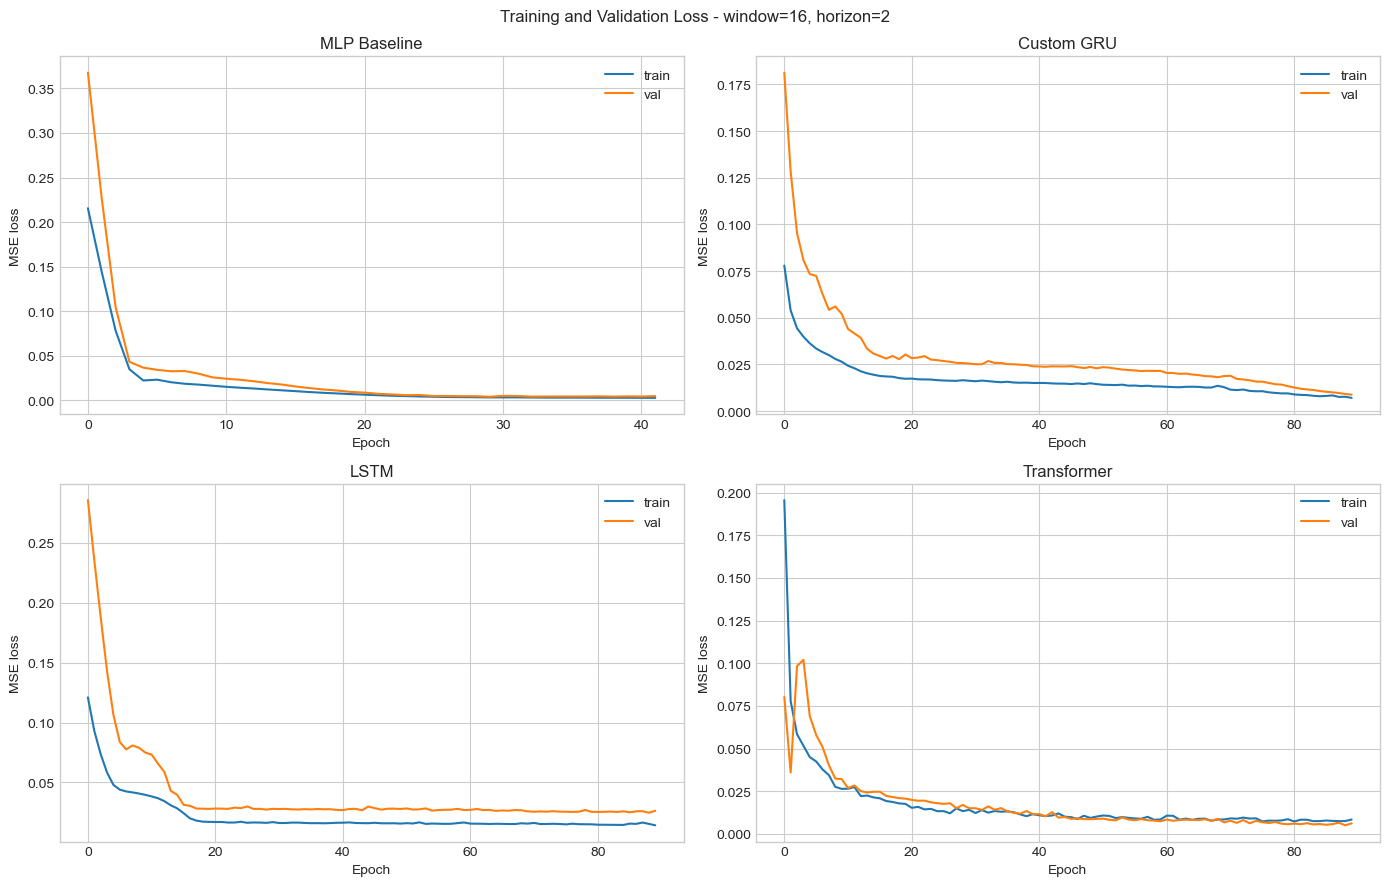

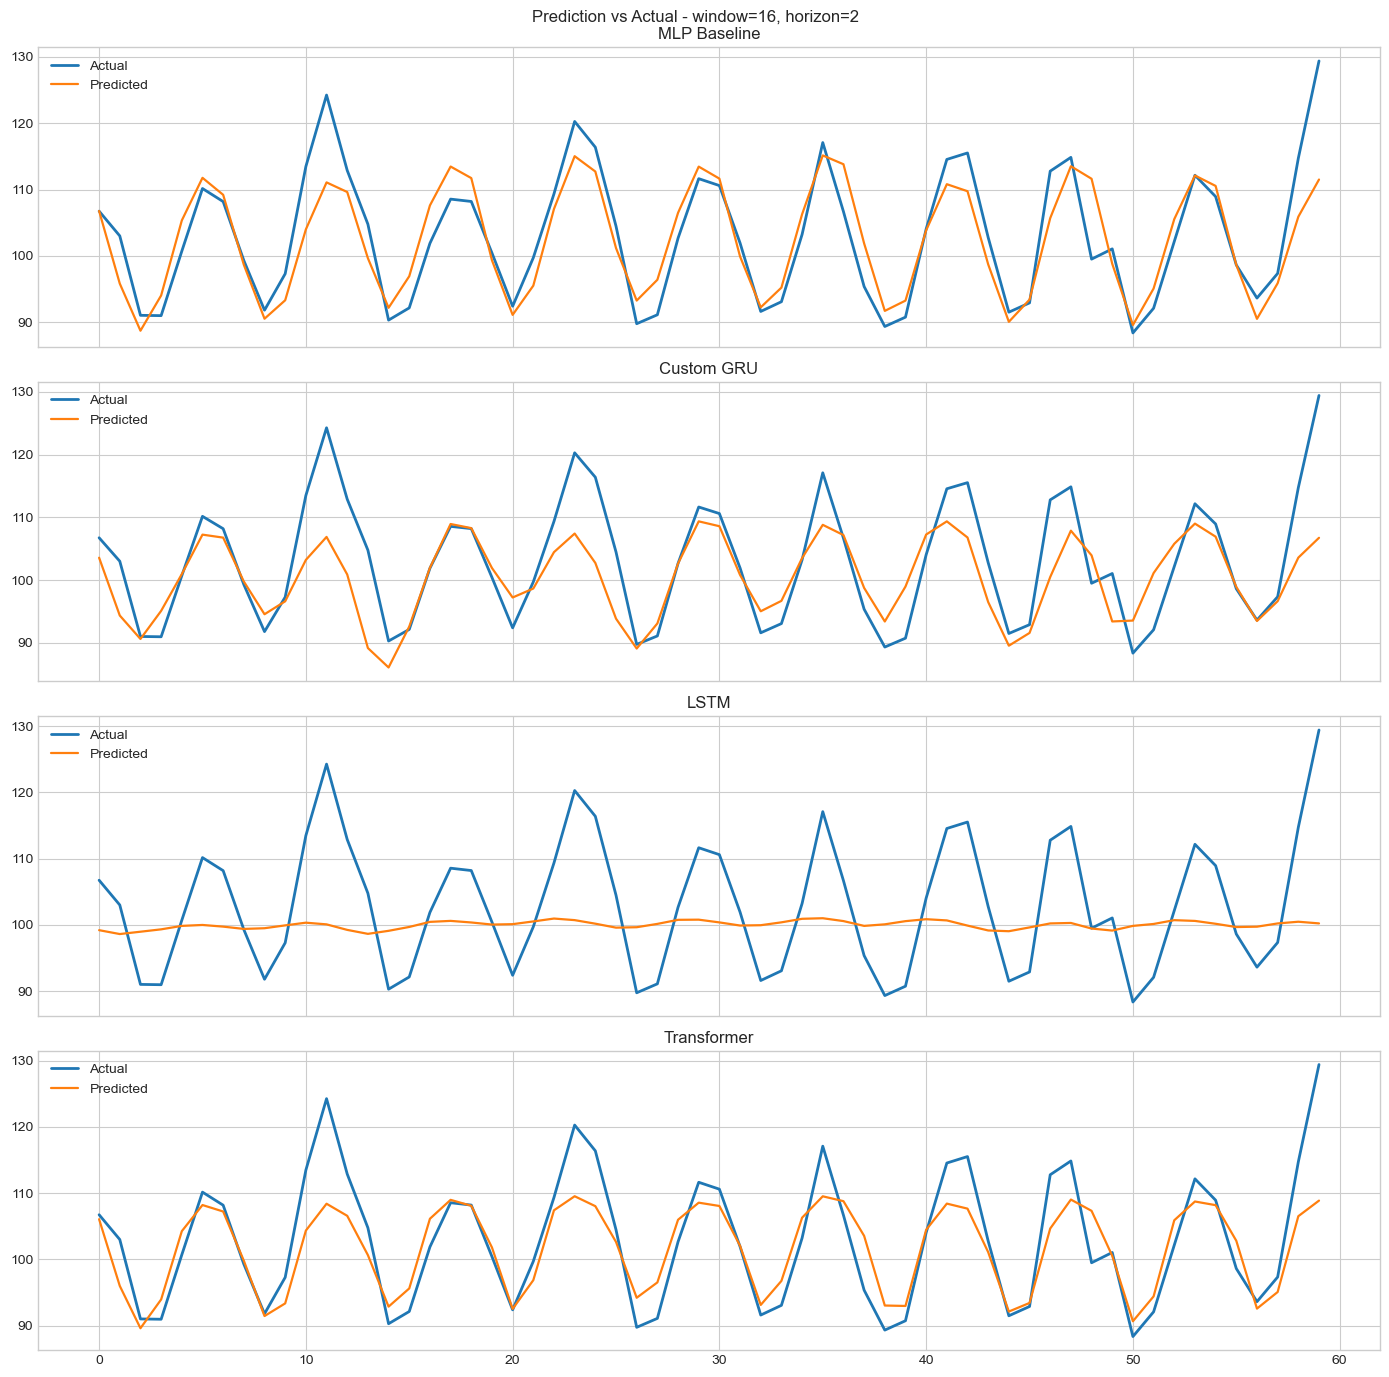

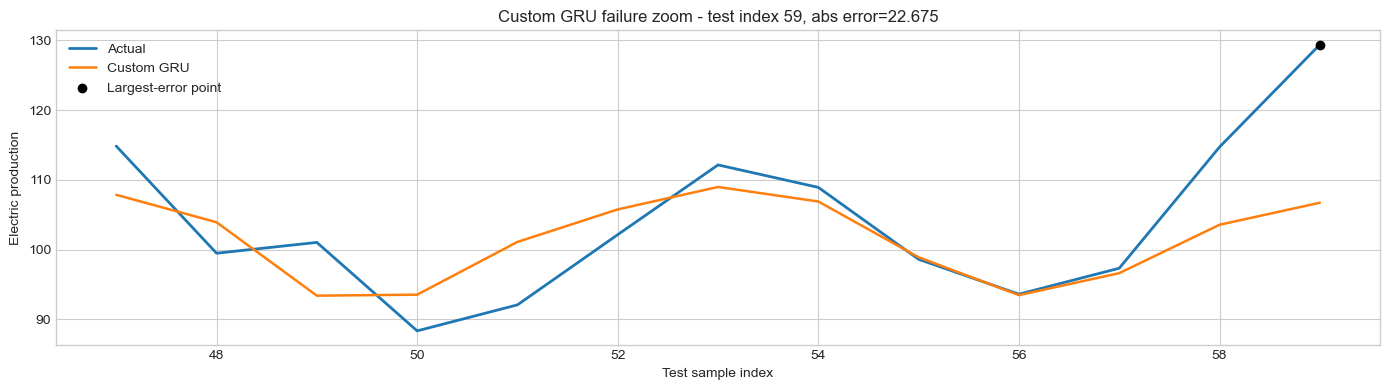

Largest custom-GRU error occurs near test index 59: actual=129.405, predicted=106.730, abs_error=22.675


In [5]:
original_window_size = window_size
train_loader, val_loader, test_loader, _ = make_loaders(original_window_size, prediction_horizon)

model_builders = {
    "MLP Baseline": lambda: MLPBaseline(original_window_size, hidden_size),
    "Custom GRU": lambda: CustomGRUForecaster(hidden_size),
    "LSTM": lambda: LSTMForecaster(hidden_size),
    "Transformer": lambda: TransformerForecaster(hidden_size),
}

original_histories = {}
original_predictions = {}
original_metrics = []
original_actual = None

for model_name, build_model in model_builders.items():
    model = build_model().to(device)
    lr = 8e-4 if model_name == "Transformer" else 1e-3
    history = train_model(model, train_loader, val_loader, epochs=90, lr=lr, patience=12)
    metrics, actual, predicted = evaluate_model(model, test_loader)
    original_histories[model_name] = history
    original_predictions[model_name] = predicted
    original_actual = actual
    original_metrics.append({"Model": model_name, **metrics})
    print(f"{model_name}: MSE={metrics['MSE']:.4f}, MAE={metrics['MAE']:.4f}, RMSE={metrics['RMSE']:.4f}")

original_results = pd.DataFrame(original_metrics).sort_values("RMSE").reset_index(drop=True)
print("\nOriginal window comparison (chronological split only):")
print(original_results.to_string(index=False))

plot_loss_curves(original_histories, f"Training and Validation Loss - window={original_window_size}, horizon={prediction_horizon}")
plot_prediction_grid(original_actual, original_predictions, f"Prediction vs Actual - window={original_window_size}, horizon={prediction_horizon}")

custom_abs_error = np.abs(original_actual - original_predictions["Custom GRU"])
worst_index = int(np.argmax(custom_abs_error))
zoom_start = max(0, worst_index - 12)
zoom_end = min(len(original_actual), worst_index + 13)
plt.figure(figsize=(14, 4))
plt.plot(range(zoom_start, zoom_end), original_actual[zoom_start:zoom_end], label="Actual", linewidth=2)
plt.plot(range(zoom_start, zoom_end), original_predictions["Custom GRU"][zoom_start:zoom_end], label="Custom GRU", linewidth=1.8)
plt.scatter([worst_index], [original_actual[worst_index]], color="black", zorder=5, label="Largest-error point")
plt.title(f"Custom GRU failure zoom - test index {worst_index}, abs error={custom_abs_error[worst_index]:.3f}")
plt.xlabel("Test sample index")
plt.ylabel("Electric production")
plt.legend()
plt.tight_layout()
plt.show()

print(
    f"Largest custom-GRU error occurs near test index {worst_index}: "
    f"actual={original_actual[worst_index]:.3f}, predicted={original_predictions['Custom GRU'][worst_index]:.3f}, "
    f"abs_error={custom_abs_error[worst_index]:.3f}"
)


Half window (window=8): MSE=111.1629, MAE=8.4647, RMSE=10.5434, delta_RMSE=+3.6330
Original window (window=16): MSE=90.4591, MAE=7.7067, RMSE=9.5110, delta_RMSE=+2.6006
Double window (window=32): MSE=101.6823, MAE=8.2501, RMSE=10.0838, delta_RMSE=+3.1734

Custom GRU ablation results:
 Window setting  Window size        MSE      MAE      RMSE  Delta RMSE vs original
    Half window            8 111.162887 8.464671 10.543381                3.633029
Original window           16  90.459096 7.706690  9.510999                2.600646
  Double window           32 101.682299 8.250107 10.083764                3.173412


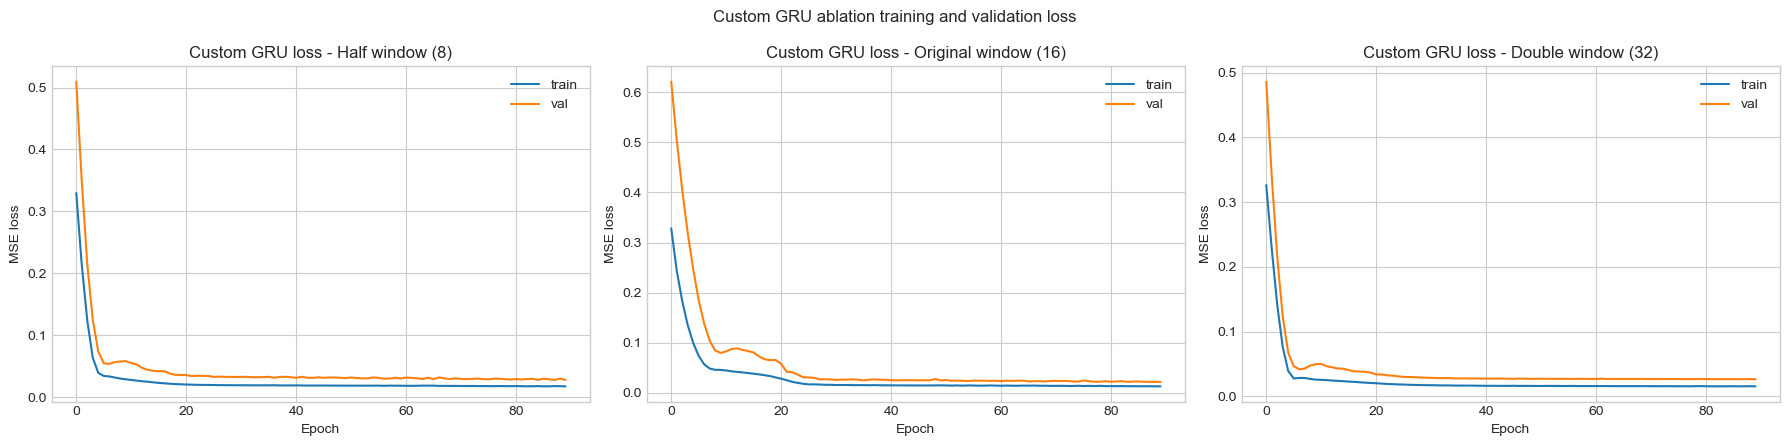

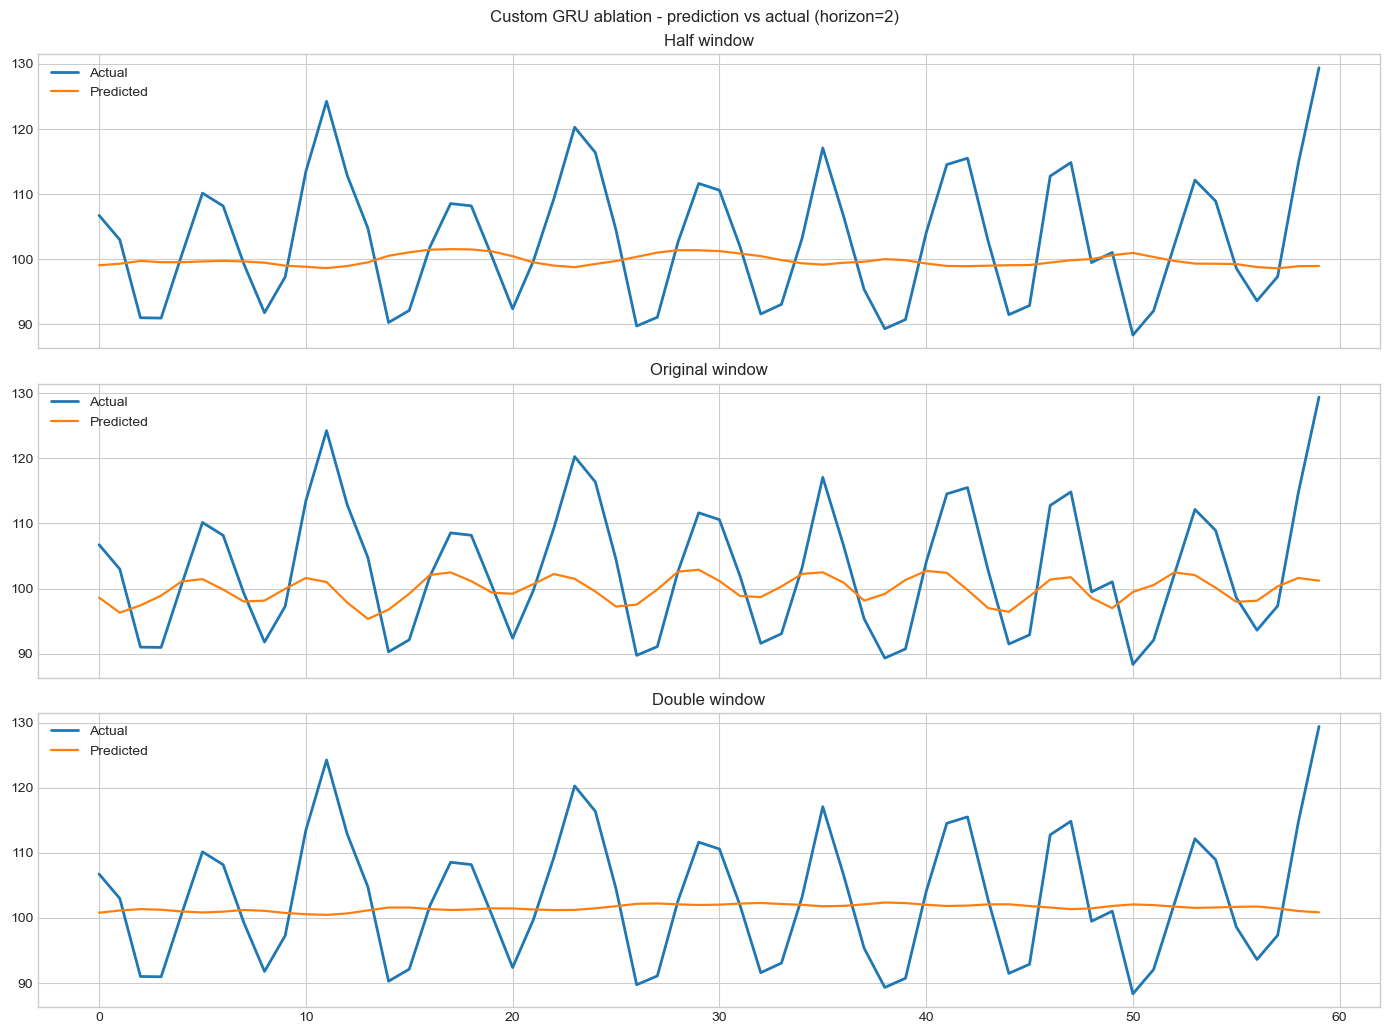

Worst ablation setting: Half window (window=8), RMSE=10.5434, which is +3.6330 vs the original window.


In [6]:
ablation_windows = {
    "Half window": max(2, window_size // 2),
    "Original window": window_size,
    "Double window": window_size * 2,
}

ablation_histories = {}
ablation_predictions = {}
ablation_metrics = []
ablation_actual = None
original_custom_rmse = float(original_results.loc[original_results["Model"] == "Custom GRU", "RMSE"].iloc[0])

for label, ablation_window in ablation_windows.items():
    train_loader, val_loader, test_loader, _ = make_loaders(ablation_window, prediction_horizon)
    model = CustomGRUForecaster(hidden_size).to(device)
    history = train_model(model, train_loader, val_loader, epochs=90, lr=1e-3, patience=12)
    metrics, actual, predicted = evaluate_model(model, test_loader)

    ablation_histories[label] = history
    ablation_predictions[label] = predicted
    ablation_actual = actual
    ablation_metrics.append(
        {
            "Window setting": label,
            "Window size": ablation_window,
            **metrics,
            "Delta RMSE vs original": metrics["RMSE"] - original_custom_rmse,
        }
    )
    print(
        f"{label} (window={ablation_window}): MSE={metrics['MSE']:.4f}, MAE={metrics['MAE']:.4f}, "
        f"RMSE={metrics['RMSE']:.4f}, delta_RMSE={metrics['RMSE'] - original_custom_rmse:+.4f}"
    )

ablation_results = pd.DataFrame(ablation_metrics).sort_values("Window size").reset_index(drop=True)
print("\nCustom GRU ablation results:")
print(ablation_results.to_string(index=False))

figure, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharey=False)
for axis, (label, history) in zip(axes, ablation_histories.items()):
    axis.plot(history["train_loss"], label="train")
    axis.plot(history["val_loss"], label="val")
    axis.set_title(f"Custom GRU loss - {label} ({ablation_windows[label]})")
    axis.set_xlabel("Epoch")
    axis.set_ylabel("MSE loss")
    axis.legend()
figure.suptitle("Custom GRU ablation training and validation loss")
figure.tight_layout()
plt.show()

plot_prediction_grid(ablation_actual, ablation_predictions, f"Custom GRU ablation - prediction vs actual (horizon={prediction_horizon})")

worst_setting = ablation_results.sort_values("RMSE", ascending=False).iloc[0]
print(
    f"Worst ablation setting: {worst_setting['Window setting']} (window={int(worst_setting['Window size'])}), "
    f"RMSE={worst_setting['RMSE']:.4f}, which is {worst_setting['Delta RMSE vs original']:+.4f} vs the original window."
)
